In [1]:
from pathlib import Path
import pandas as pd
import nibabel as nib
from nilearn import image, plotting

sub = "sub-P10"
ses = "ses-01"

func_dir = Path("data/fmriprep_output") / sub / ses / "func"
events_dir = Path("data/bids_ackbar") / sub / ses / "func"

bold_file = func_dir / f"{sub}_{ses}_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz"
mask_file = func_dir / f"{sub}_{ses}_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-brain_mask.nii.gz"
events_file = events_dir / f"{sub}_{ses}_task-viewing_run-01_events.tsv"

bold_img = nib.load(bold_file)
mask_img = nib.load(mask_file)
events = pd.read_csv(events_file, sep="\t")

print("BOLD shape:", bold_img.shape)
print("Events shape:", events.shape)
events.head()

BOLD shape: (62, 77, 66, 2026)
Events shape: (384, 7)


,onset,duration,event,button_pressed,answer,HumanAppearOnThe,reaction_time
0,4.634,3.017,maya_3_e3_6_r_h_v1_old.jpg,1,2.0,Right,1.822
1,11.701,3.017,wealth_5_e3_7_nr_o_v1_old.jpg,1,1.0,Right,0.582
2,17.934,3.017,pirate_6_e2_13_r_h_v1_old.jpg,1,2.0,Right,0.561
3,24.534,3.017,viking_11_new.jpg,1,2.0,Right,0.469
4,30.451,3.016,pirate_7_e3_1_nr_h_v1_old.jpg,1,2.0,Right,0.448


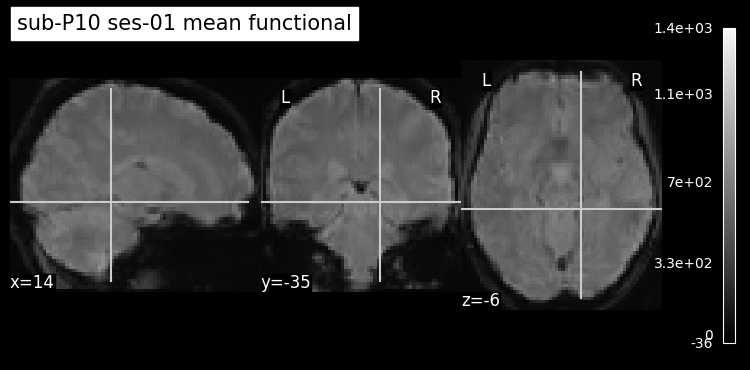

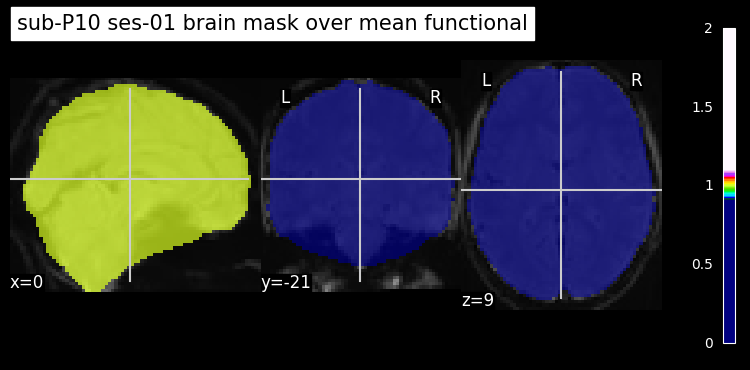

In [2]:
from nilearn import image, plotting

mean_img = image.mean_img(bold_img)

plotting.plot_anat(
    mean_img,
    title=f"{sub} {ses} mean functional",
    display_mode="ortho"
)

plotting.plot_roi(
    mask_img,
    bg_img=mean_img,
    title=f"{sub} {ses} brain mask over mean functional",
    display_mode="ortho"
)

/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



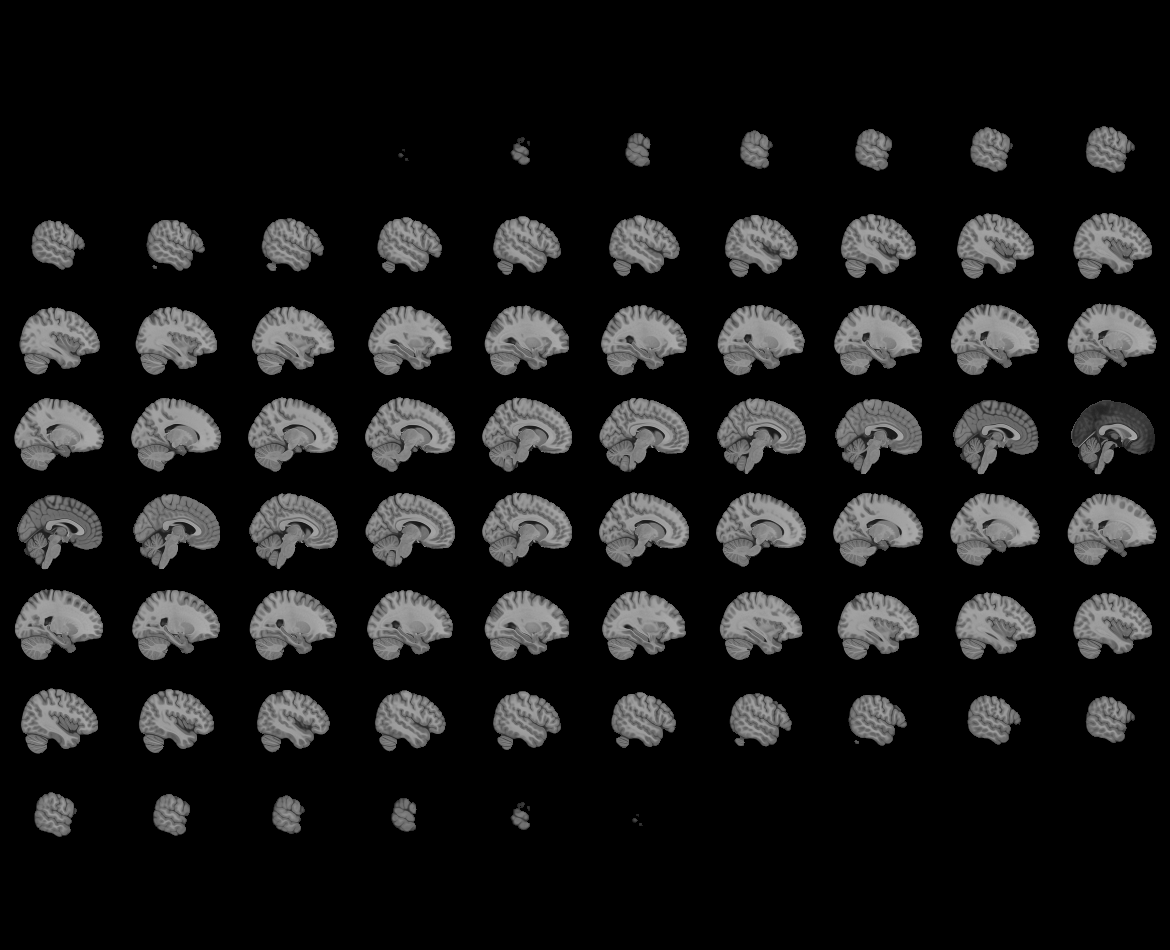
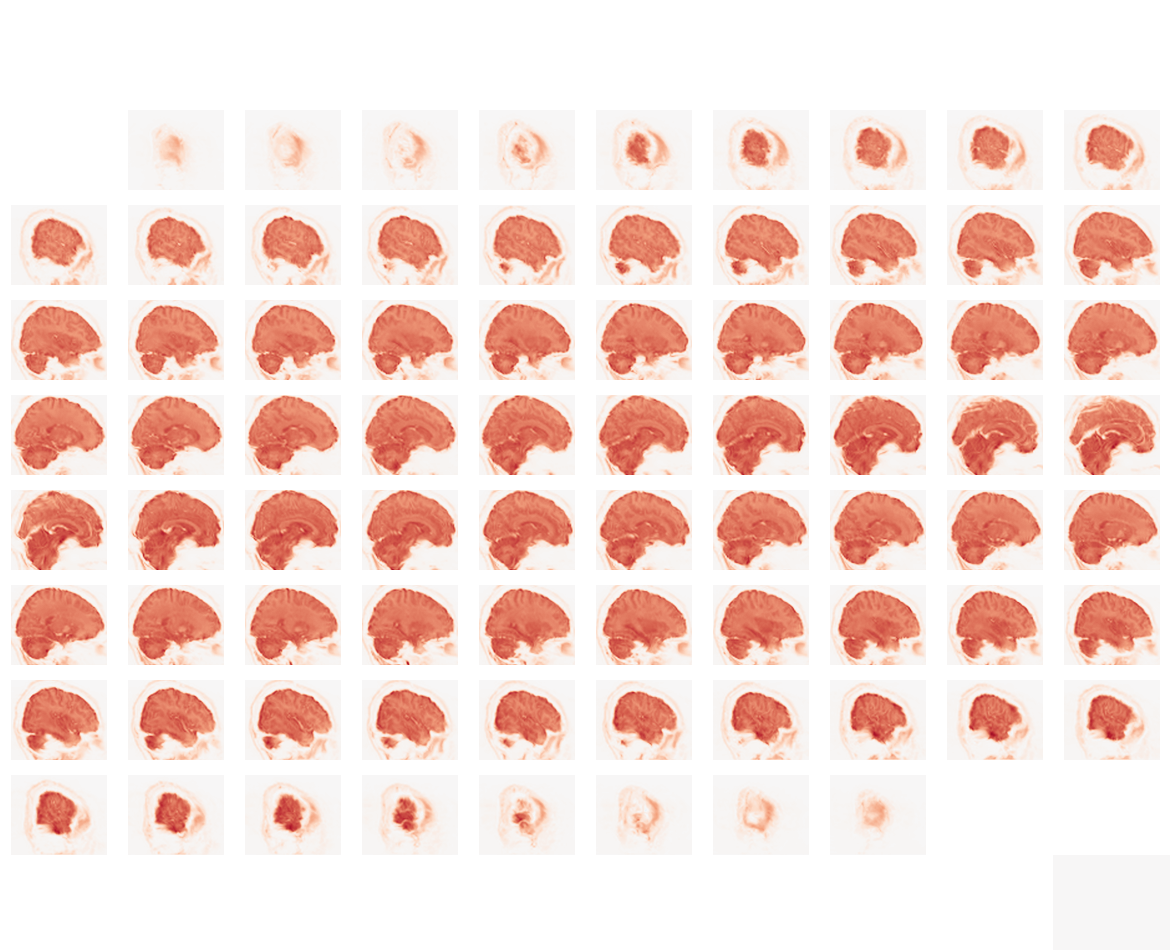

In [3]:
view = plotting.view_img(mean_img, title=f"{sub} {ses} mean functional")
view

In [4]:
events_parsed = events.copy()

events_parsed["is_old"] = events_parsed["event"].str.contains("_old", na=False)
events_parsed["is_new"] = events_parsed["event"].str.contains("_new", na=False)
events_parsed["is_relevant"] = events_parsed["event"].str.contains("_r_", na=False)
events_parsed["is_irrelevant"] = events_parsed["event"].str.contains("_nr_", na=False)
events_parsed["is_human"] = events_parsed["event"].str.contains("_h_", na=False)
events_parsed["is_object"] = events_parsed["event"].str.contains("_o_", na=False)

events_parsed[[
    "event",
    "is_old",
    "is_new",
    "is_relevant",
    "is_irrelevant",
    "is_human",
    "is_object",
]].head(20)

,event,is_old,is_new,is_relevant,is_irrelevant,is_human,is_object
0,maya_3_e3_6_r_h_v1_old.jpg,True,False,True,False,True,False
1,wealth_5_e3_7_nr_o_v1_old.jpg,True,False,False,True,False,True
2,pirate_6_e2_13_r_h_v1_old.jpg,True,False,True,False,True,False
3,viking_11_new.jpg,False,True,False,False,False,False
4,pirate_7_e3_1_nr_h_v1_old.jpg,True,False,False,True,True,False
5,food_8_e3_13_r_o_v1_old.jpg,True,False,True,False,False,True
6,pirate_8_e2_6_r_h_v1_old.jpg,True,False,True,False,True,False
7,food_9_new.jpg,False,True,False,False,False,False
8,viking_3_e2_1_nr_h_v1_old.jpg,True,False,False,True,True,False
9,food_6_e2_2_nr_o_v1_old.jpg,True,False,False,True,False,True


In [5]:
events_parsed[[
    "is_old",
    "is_new",
    "is_relevant",
    "is_irrelevant",
    "is_human",
    "is_object",
]].sum()

is_old           288
is_new            96
is_relevant      144
is_irrelevant    144
is_human         144
is_object        144
dtype: int64

In [6]:
import pandas as pd

def parse_event_name(filename):
    name = filename.replace(".jpg", "")
    parts = name.split("_")
    
    # Example old:
    # maya_3_e3_6_r_h_v1_old
    if "old" in parts and len(parts) >= 8:
        return pd.Series({
            "stim_cat": parts[0],
            "list_no": parts[1],
            "encoding_session": parts[2],
            "checkpoint_or_stim_no": parts[3],
            "relevance": parts[4],
            "human_object": parts[5],
            "version": parts[6],
            "old_new": parts[7],
        })
    
    # Example new:
    # viking_11_new
    return pd.Series({
        "stim_cat": parts[0] if len(parts) > 0 else None,
        "list_no": None,
        "encoding_session": None,
        "checkpoint_or_stim_no": parts[1] if len(parts) > 1 else None,
        "relevance": None,
        "human_object": None,
        "version": None,
        "old_new": "new" if "new" in parts else None,
    })

parsed_cols = events_parsed["event"].apply(parse_event_name)
events_parsed = pd.concat([events_parsed, parsed_cols], axis=1)

events_parsed.head(20)

,onset,duration,event,button_pressed,answer,HumanAppearOnThe,reaction_time,is_old,is_new,is_relevant,...,is_human,is_object,stim_cat,list_no,encoding_session,checkpoint_or_stim_no,relevance,human_object,version,old_new
0,4.634,3.017,maya_3_e3_6_r_h_v1_old.jpg,1,2.0,Right,1.822,True,False,True,...,True,False,maya,3,e3,6,r,h,v1,old
1,11.701,3.017,wealth_5_e3_7_nr_o_v1_old.jpg,1,1.0,Right,0.582,True,False,False,...,False,True,wealth,5,e3,7,nr,o,v1,old
2,17.934,3.017,pirate_6_e2_13_r_h_v1_old.jpg,1,2.0,Right,0.561,True,False,True,...,True,False,pirate,6,e2,13,r,h,v1,old
3,24.534,3.017,viking_11_new.jpg,1,2.0,Right,0.469,False,True,False,...,False,False,viking,None,None,11,None,None,None,new
4,30.451,3.016,pirate_7_e3_1_nr_h_v1_old.jpg,1,2.0,Right,0.448,True,False,False,...,True,False,pirate,7,e3,1,nr,h,v1,old
5,37.151,3.016,food_8_e3_13_r_o_v1_old.jpg,1,1.0,Right,0.366,True,False,True,...,False,True,food,8,e3,13,r,o,v1,old
6,43.367,3.017,pirate_8_e2_6_r_h_v1_old.jpg,1,2.0,Right,0.335,True,False,True,...,True,False,pirate,8,e2,6,r,h,v1,old
7,48.551,3.016,food_9_new.jpg,1,1.0,Right,0.768,False,True,False,...,False,False,food,None,None,9,None,None,None,new
8,54.367,3.017,viking_3_e2_1_nr_h_v1_old.jpg,1,2.0,Right,1.589,True,False,False,...,True,False,viking,3,e2,1,nr,h,v1,old
9,61.800,3.017,food_6_e2_2_nr_o_v1_old.jpg,1,1.0,Right,0.377,True,False,False,...,False,True,food,6,e2,2,nr,o,v1,old


In [7]:
events_parsed.groupby(
    ["old_new", "encoding_session", "relevance", "human_object"],
    dropna=False
).size()

old_new  encoding_session  relevance  human_object
new      NaN               NaN        NaN             96
old      e1                nr         h               24
                                      o               24
                           r          h               24
                                      o               24
         e2                nr         h               24
                                      o               24
                           r          h               24
                                      o               24
         e3                nr         h               24
                                      o               24
                           r          h               24
                                      o               24
dtype: int64

In [8]:
events_parsed.groupby(["stim_cat", "old_new"], dropna=False).size()

stim_cat  old_new
drink     new        12
          old        48
food      new        18
          old        48
maya      new        18
          old        48
pirate    new        12
          old        48
viking    new        18
          old        48
wealth    new        18
          old        48
dtype: int64

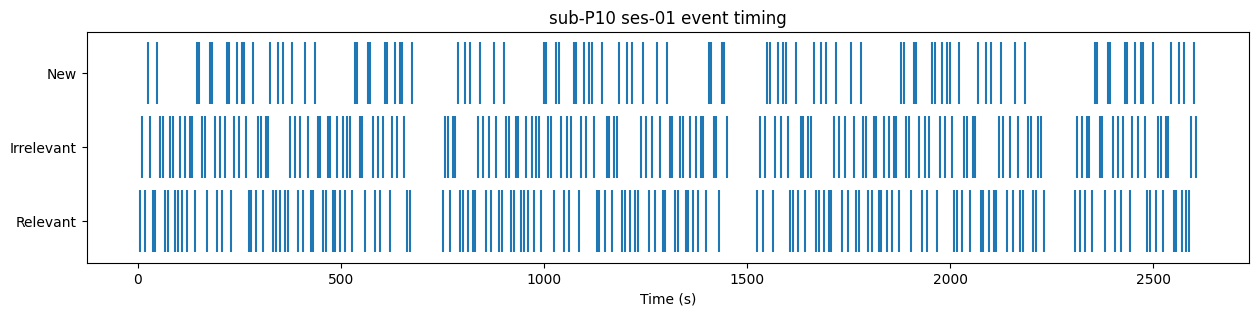

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 3))

plt.vlines(
    events_parsed.loc[events_parsed["is_relevant"], "onset"],
    0, 1,
    label="Relevant"
)

plt.vlines(
    events_parsed.loc[events_parsed["is_irrelevant"], "onset"],
    1.2, 2.2,
    label="Irrelevant"
)

plt.vlines(
    events_parsed.loc[events_parsed["is_new"], "onset"],
    2.4, 3.4,
    label="New"
)

plt.xlabel("Time (s)")
plt.yticks([0.5, 1.7, 2.9], ["Relevant", "Irrelevant", "New"])
plt.title(f"{sub} {ses} event timing")
plt.show()

In [10]:
from pathlib import Path
from nilearn import plotting

contrast_dir = Path("data/processed/glm/faces_vs_objects/sub-P10")

pre_zmap = contrast_dir / "sub-P10_smooth_None_faces_vs_objects_pre_contrast.nii.gz"
post_zmap = contrast_dir / "sub-P10_smooth_None_faces_vs_objects_post_contrast.nii.gz"
prepost_zmap = contrast_dir / "sub-P10_smooth_None_faces_vs_objects_pre-post_contrast.nii.gz"

print(pre_zmap.exists(), post_zmap.exists(), prepost_zmap.exists())

True True True


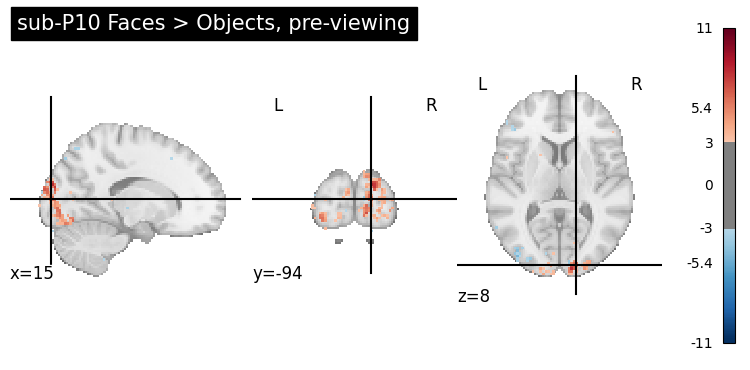

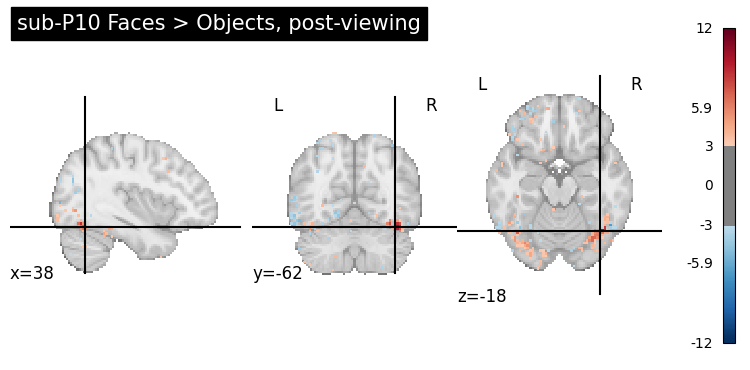

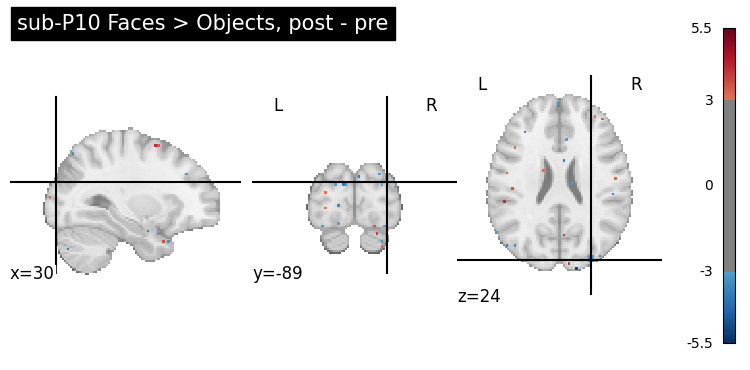

In [11]:
plotting.plot_stat_map(
    str(pre_zmap),
    threshold=3.0,
    display_mode="ortho",
    title="sub-P10 Faces > Objects, pre-viewing"
)

plotting.plot_stat_map(
    str(post_zmap),
    threshold=3.0,
    display_mode="ortho",
    title="sub-P10 Faces > Objects, post-viewing"
)

plotting.plot_stat_map(
    str(prepost_zmap),
    threshold=3.0,
    display_mode="ortho",
    title="sub-P10 Faces > Objects, post - pre"
)

/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



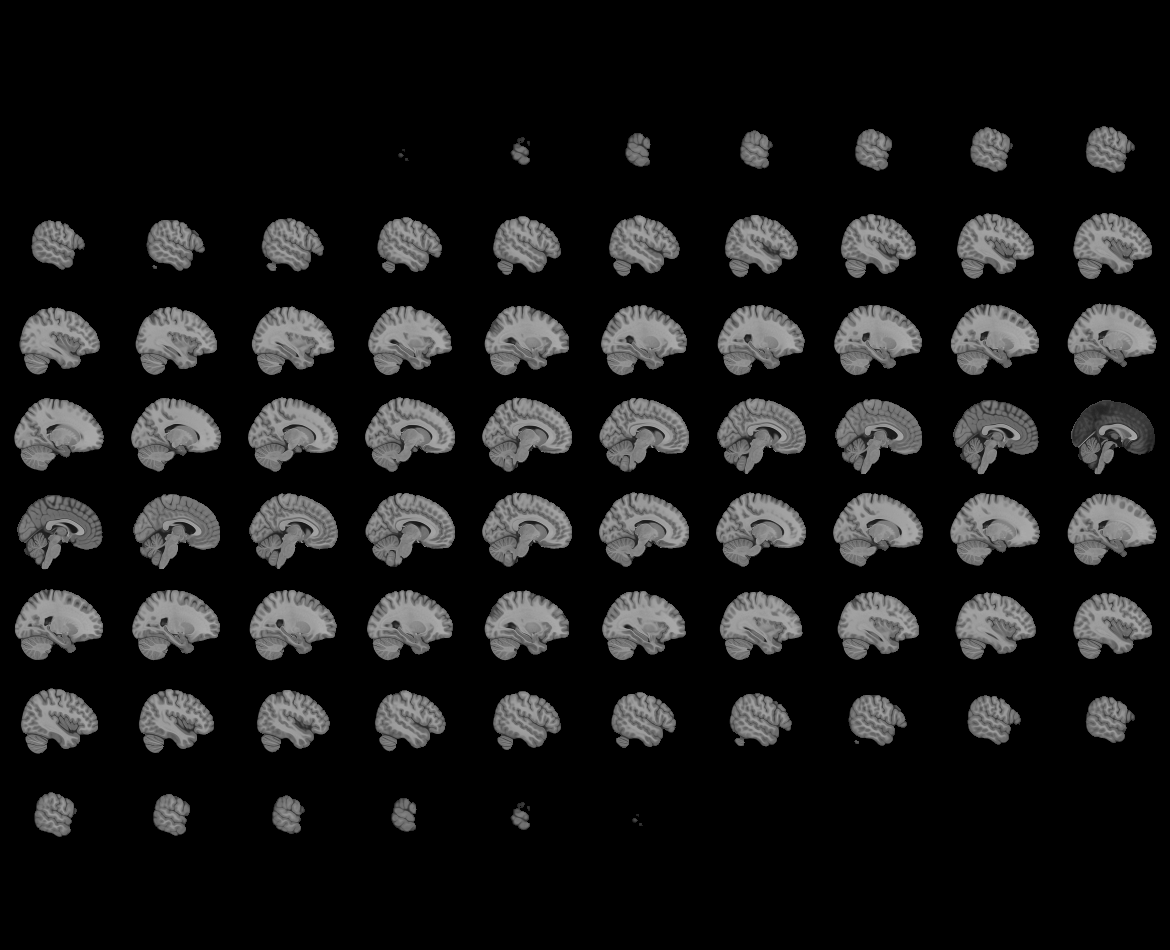
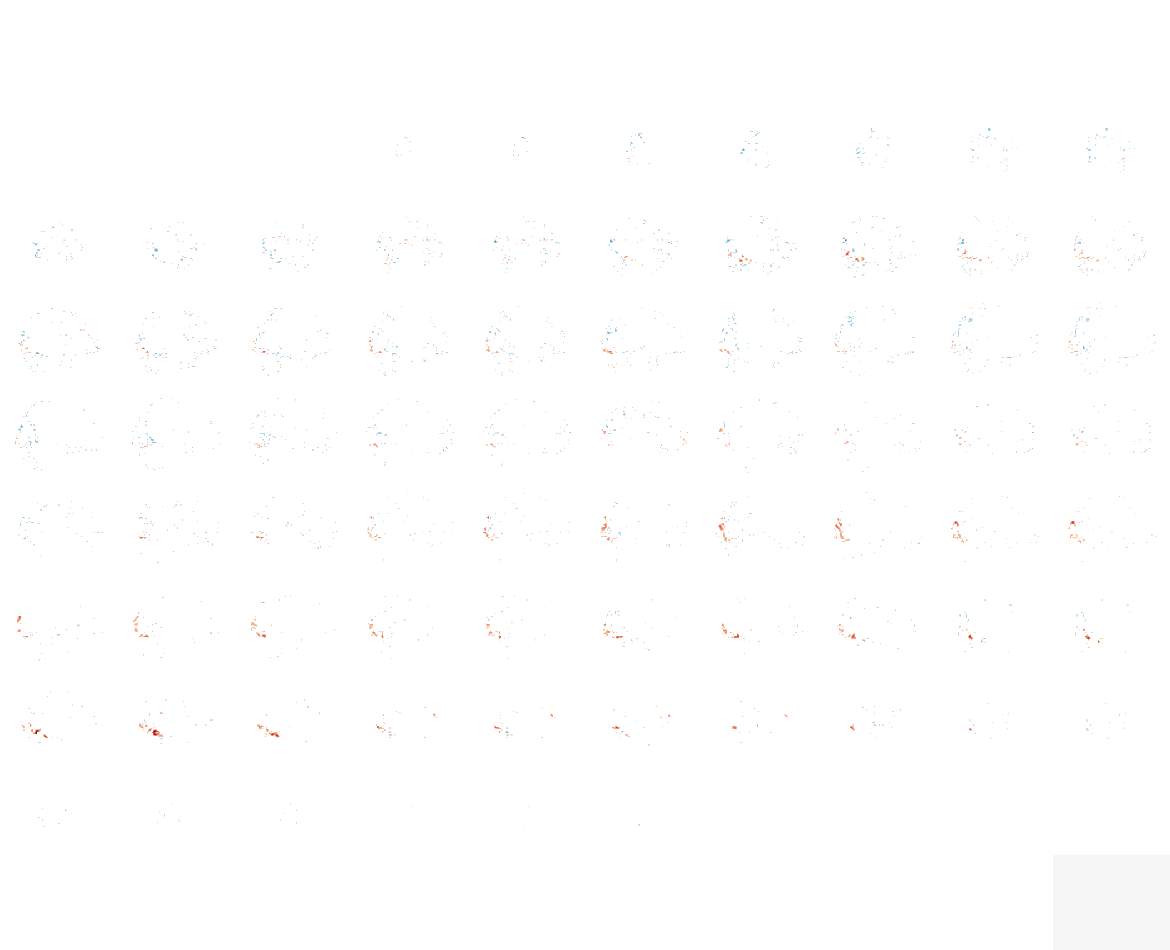

In [12]:
view = plotting.view_img(str(post_zmap), threshold=3.0, title="sub-P10 Faces > Objects post")
view

True True True


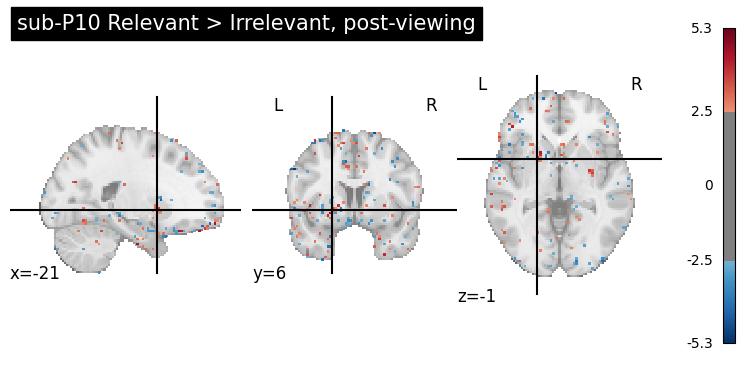

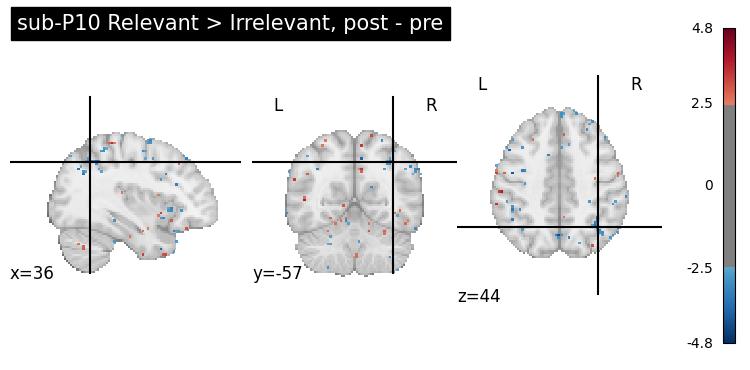

In [13]:
from pathlib import Path
from nilearn import plotting

contrast_dir = Path("data/processed/glm/relevance_vs_irrelevance/sub-P10")

pre_zmap = contrast_dir / "sub-P10_smooth_None_relevance_vs_irrelevance_pre_contrast.nii.gz"
post_zmap = contrast_dir / "sub-P10_smooth_None_relevance_vs_irrelevance_post_contrast.nii.gz"
prepost_zmap = contrast_dir / "sub-P10_smooth_None_relevance_vs_irrelevance_pre-post_contrast.nii.gz"

print(pre_zmap.exists(), post_zmap.exists(), prepost_zmap.exists())

plotting.plot_stat_map(str(post_zmap), threshold=2.5, display_mode="ortho",
                       title="sub-P10 Relevant > Irrelevant, post-viewing")

plotting.plot_stat_map(str(prepost_zmap), threshold=2.5, display_mode="ortho",
                       title="sub-P10 Relevant > Irrelevant, post - pre")

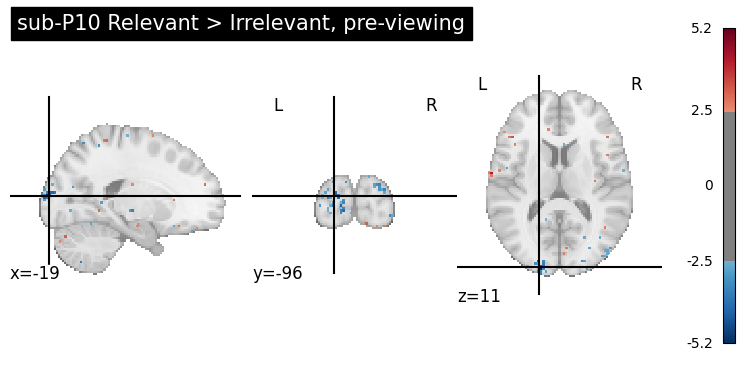

In [14]:
plotting.plot_stat_map(
    str(pre_zmap),
    threshold=2.5,
    display_mode="ortho",
    title="sub-P10 Relevant > Irrelevant, pre-viewing"
)

In [15]:
from pathlib import Path
from nilearn import plotting, image
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib

sub = "sub-P10"

nosmooth_dir = Path("data/processed/glm/relevance_vs_irrelevance/sub-P10")
smooth_dir = Path("data/processed/glm/relevance_vs_irrelevance_smooth5/sub-P10")

maps = {
    "pre_nosmooth": nosmooth_dir / "sub-P10_smooth_None_relevance_vs_irrelevance_pre_contrast.nii.gz",
    "post_nosmooth": nosmooth_dir / "sub-P10_smooth_None_relevance_vs_irrelevance_post_contrast.nii.gz",
    "prepost_nosmooth": nosmooth_dir / "sub-P10_smooth_None_relevance_vs_irrelevance_pre-post_contrast.nii.gz",
    "pre_smooth5": smooth_dir / "sub-P10_smooth_5_relevance_vs_irrelevance_pre_contrast.nii.gz",
    "post_smooth5": smooth_dir / "sub-P10_smooth_5_relevance_vs_irrelevance_post_contrast.nii.gz",
    "prepost_smooth5": smooth_dir / "sub-P10_smooth_5_relevance_vs_irrelevance_pre-post_contrast.nii.gz",
}

for name, path in maps.items():
    print(name, path.exists(), path)

pre_nosmooth True data/processed/glm/relevance_vs_irrelevance/sub-P10/sub-P10_smooth_None_relevance_vs_irrelevance_pre_contrast.nii.gz
post_nosmooth True data/processed/glm/relevance_vs_irrelevance/sub-P10/sub-P10_smooth_None_relevance_vs_irrelevance_post_contrast.nii.gz
prepost_nosmooth True data/processed/glm/relevance_vs_irrelevance/sub-P10/sub-P10_smooth_None_relevance_vs_irrelevance_pre-post_contrast.nii.gz
pre_smooth5 True data/processed/glm/relevance_vs_irrelevance_smooth5/sub-P10/sub-P10_smooth_5_relevance_vs_irrelevance_pre_contrast.nii.gz
post_smooth5 True data/processed/glm/relevance_vs_irrelevance_smooth5/sub-P10/sub-P10_smooth_5_relevance_vs_irrelevance_post_contrast.nii.gz
prepost_smooth5 True data/processed/glm/relevance_vs_irrelevance_smooth5/sub-P10/sub-P10_smooth_5_relevance_vs_irrelevance_pre-post_contrast.nii.gz


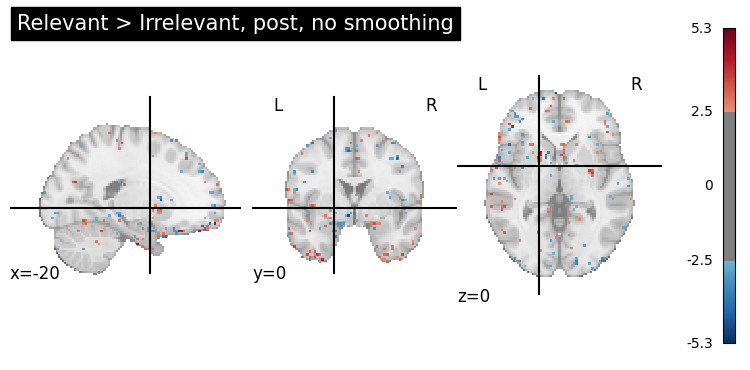

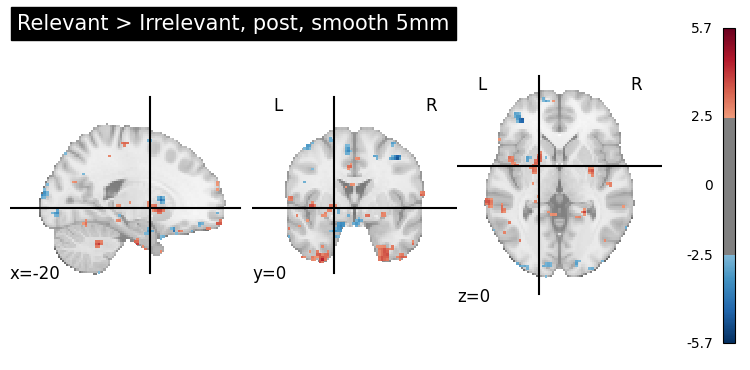

In [16]:
cut_coords = (-20, 0, 0)  # you can adjust later
threshold = 2.5

plotting.plot_stat_map(
    str(maps["post_nosmooth"]),
    threshold=threshold,
    display_mode="ortho",
    cut_coords=cut_coords,
    title="Relevant > Irrelevant, post, no smoothing",
)

plotting.plot_stat_map(
    str(maps["post_smooth5"]),
    threshold=threshold,
    display_mode="ortho",
    cut_coords=cut_coords,
    title="Relevant > Irrelevant, post, smooth 5mm",
)

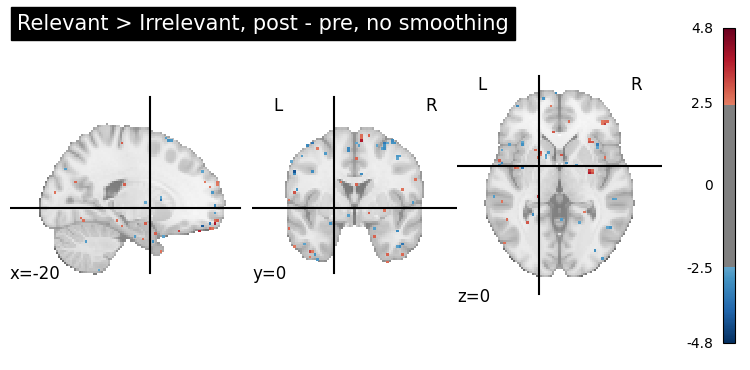

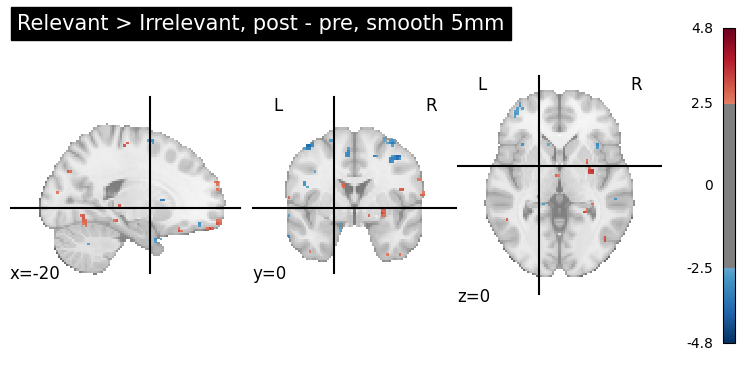

In [17]:
plotting.plot_stat_map(
    str(maps["prepost_nosmooth"]),
    threshold=threshold,
    display_mode="ortho",
    cut_coords=cut_coords,
    title="Relevant > Irrelevant, post - pre, no smoothing",
)

plotting.plot_stat_map(
    str(maps["prepost_smooth5"]),
    threshold=threshold,
    display_mode="ortho",
    cut_coords=cut_coords,
    title="Relevant > Irrelevant, post - pre, smooth 5mm",
)

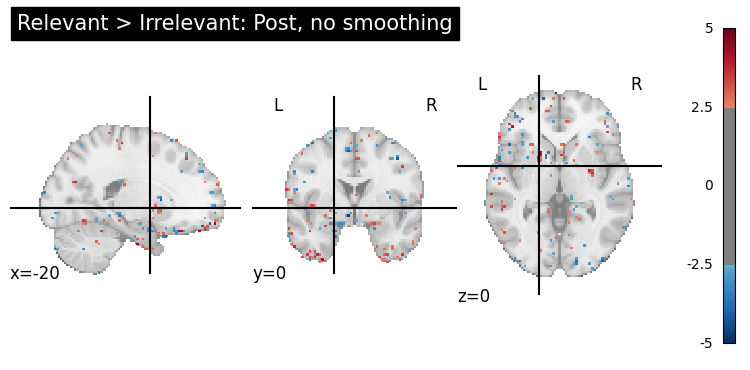

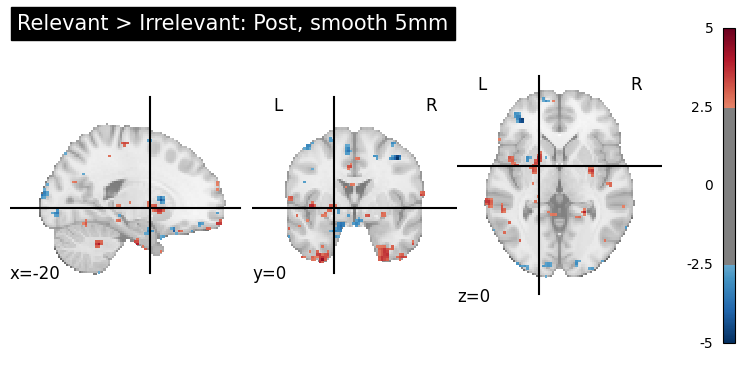

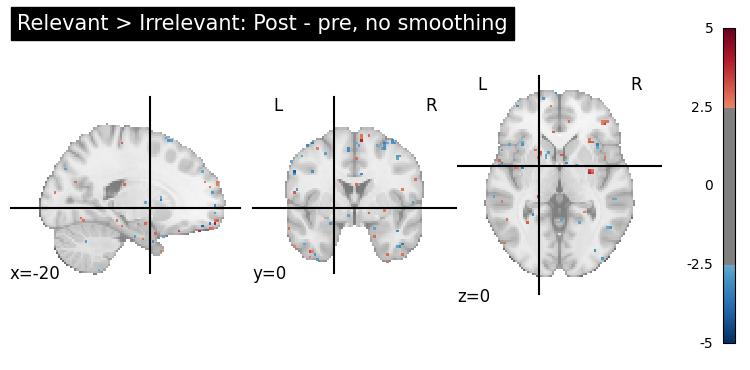

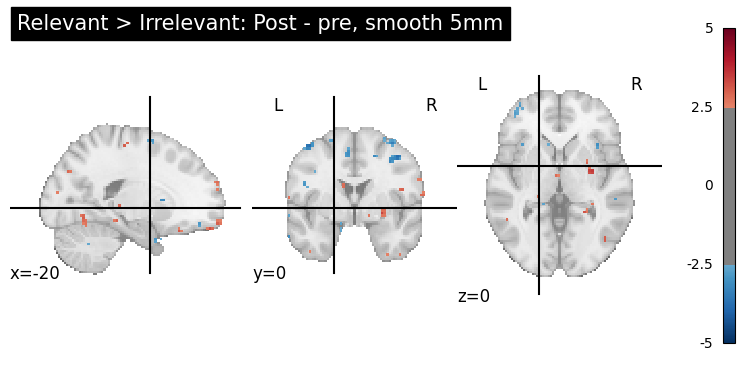

In [18]:
vmax = 5
threshold = 2.5

for key, title in [
    ("post_nosmooth", "Post, no smoothing"),
    ("post_smooth5", "Post, smooth 5mm"),
    ("prepost_nosmooth", "Post - pre, no smoothing"),
    ("prepost_smooth5", "Post - pre, smooth 5mm"),
]:
    plotting.plot_stat_map(
        str(maps[key]),
        threshold=threshold,
        vmax=vmax,
        display_mode="ortho",
        cut_coords=cut_coords,
        title=f"Relevant > Irrelevant: {title}",
    )